In [30]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Parameters, minimize
from psyduck.operations import get_spin_operators
from psyduck.hamiltonians import quadrupole_hamiltonian_from_Vab, zeeman_hamiltonian

In [83]:
Q_N = -0.69e-28
I_SPIN = 7/2
GAMMA_NUCLEAR = 5.55e6

In [102]:
# Round 2 data: 9 angles, 7 NMR transition frequencies each
nmr = np.flip(np.array([
    [5177528, 5196914, 5216357, 5235865, 5255417, 5275028, 5294686],
    [5161529, 5169044, 5176984, 5185315, 5194063, 5203187, 5212704],
    [5193097, 5181625, 5170701, 5160363, 5150582, 5141366, 5132727],
    [5061216, 5033579, 5006232, 4979215, 4952508, 4926134, 4900099],
    [4979932, 4949389, 4918974, 4888688, 4858533, 4828508, 4798611],
    [4999724, 4982724, 4965998, 4949547, 4933377, 4917481, 4901852],
    [5104750, 5108384, 5112255, 5116361, 5120679, 5125222, 5129953],
    [5097951, 5116198, 5134431, 5152658, 5170888, 5189117, 5207340],
    [5175598, 5195010, 5214485, 5234018, 5253596, 5273241, 5292925]
], dtype=float), axis=1)

thetas = np.array([0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5, 180]) / 180 * np.pi

# B0 estimated from central transition at theta=0
B0 = np.mean(nmr[0]) / GAMMA_NUCLEAR

In [103]:
def make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    return np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]]) * 1e19

def ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, phi=0.0, **kwargs):
    V_ab = make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    H_q = quadrupole_hamiltonian_from_Vab(I_SPIN, V_ab, Q_N)
    H_zeeman = zeeman_hamiltonian(7/2, B0=B0, gamma=GAMMA_NUCLEAR, theta=theta, phi=phi)
    return H_zeeman + H_q

def nmr_frequencies(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, **kwargs):
    evals = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz).eigenstates()[0]
    return np.diff(evals).flatten()

## Fit

Each angle has a slightly different effective B0 (field drift between measurements).
Subtracting the mean frequency at each angle removes this per-angle B0 offset,
leaving only the quadrupole-induced deviations (which encode the EFG tensor).

This gives 6 independent residuals per angle (7 frequencies minus 1 mean constraint)
instead of the 2 scalar quantities fq1/fq2 — a richer fit.

In [104]:
# Per-angle mean of measured frequencies (absorbs B0 variation)
nmr_means = nmr.mean(axis=1, keepdims=True)
nmr_centered = nmr - nmr_means
scale = np.abs(nmr_centered).max()

def residual(params):
    p = params.valuesdict()
    res = []
    for t, theta in enumerate(thetas):
        freq_model = nmr_frequencies(theta, **p)
        freq_model_centered = freq_model - freq_model.mean()
        res.append((freq_model_centered - nmr_centered[t]) / scale)
    return np.hstack(res)

params = Parameters()
params.add('Vxx', value=2.4,  min=-5,  max=5)
params.add('Vyy', value=-0.7, min=-5,  max=5)
params.add('Vzz', expr='-Vxx - Vyy')
params.add('Vxy', value=-1.5, min=-20, max=20)
params.add('Vyz', value=-1.2, min=-5,  max=20)
params.add('Vxz', value=0.6,  min=-5,  max=20)

result = minimize(residual, params, method='leastsq')
result.params.pretty_print()

Name     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Vxx    -2.422       -5        5  0.01756     True     None     None
Vxy    -1.421      -20       20        1     True     None     None
Vxz   -0.6005       -5       20  0.01456     True     None     None
Vyy    0.7095       -5        5  0.01964     True     None     None
Vyz     -1.24       -5       20   0.9498     True     None     None
Vzz     1.712     -inf      inf  0.01521    False -Vxx - Vyy     None


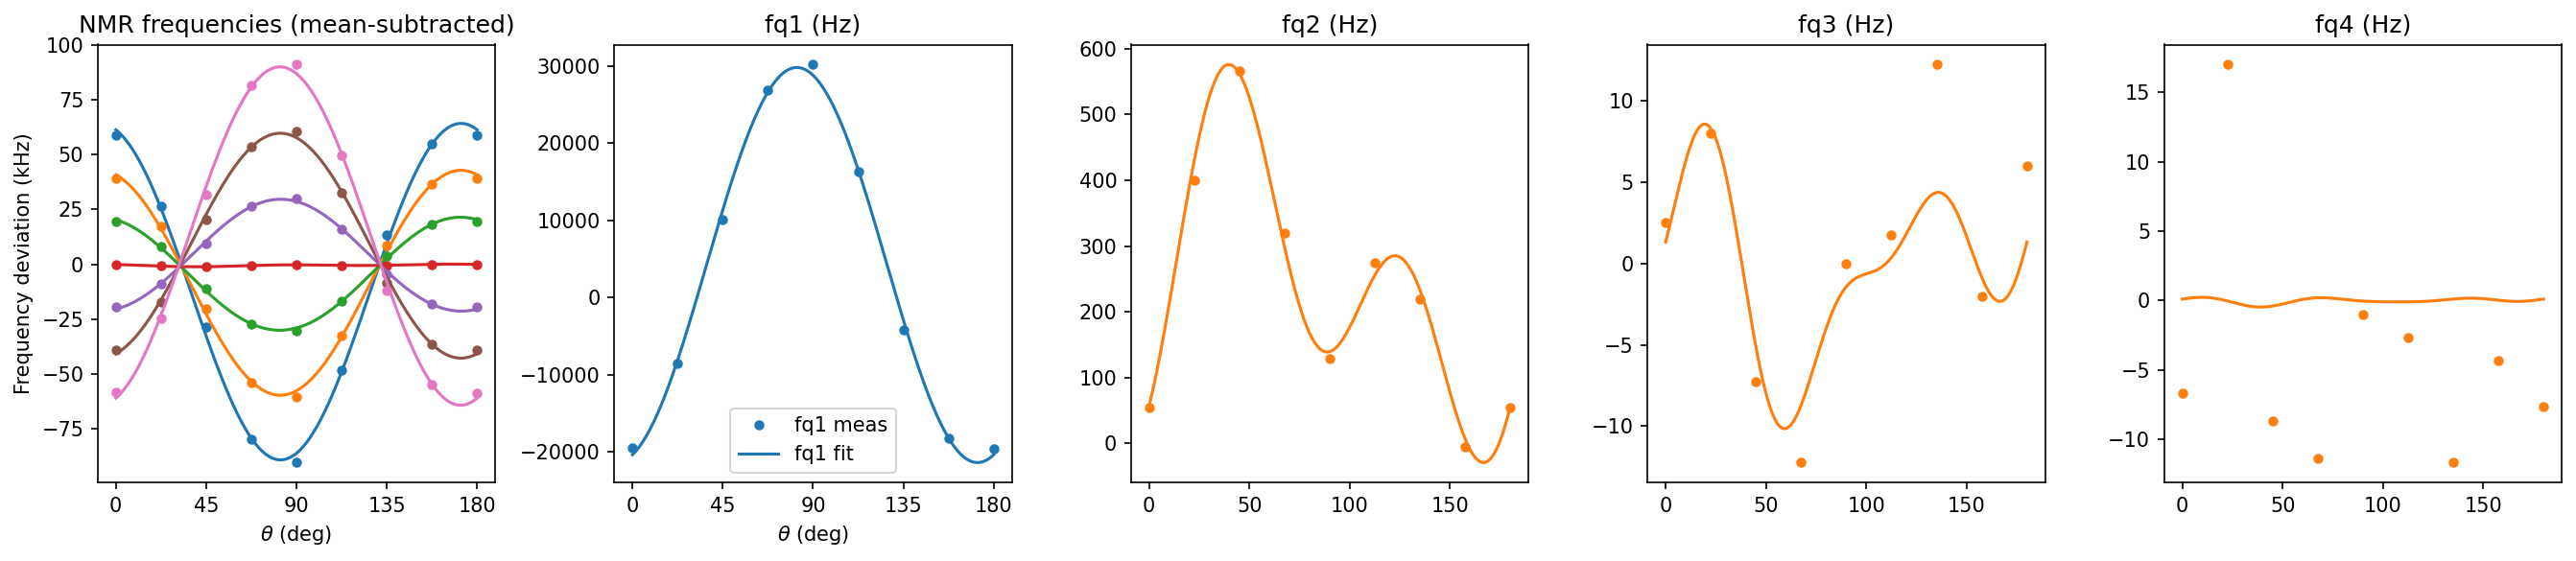

In [105]:
p = result.params.valuesdict()
thetas_fine = np.linspace(0, np.pi, 200)

nmr_model = np.array([nmr_frequencies(th, **p) for th in thetas_fine])
nmr_model_centered = nmr_model - nmr_model.mean(axis=1, keepdims=True)

colors = plt.cm.tab10.colors
theta_deg = thetas / np.pi * 180
theta_fine_deg = thetas_fine / np.pi * 180

fq1_meas = np.array([np.mean(np.diff(nmr[t])) for t in range(9)])
fq2_meas = np.array([np.mean(np.diff(np.diff(nmr[t]))) for t in range(9)])
fq3_meas = np.array([np.mean(np.diff(np.diff(np.diff(nmr[t])))) for t in range(9)])
fq4_meas = np.array([np.mean(np.diff(np.diff(np.diff(np.diff(nmr[t]))))) for t in range(9)])

fq1_model = np.array([np.mean(np.diff(np.diff(ionized_hamiltonian(th, **p).eigenstates()[0])))
                      for th in thetas_fine])
fq2_model = np.array([np.mean(np.diff(np.diff(np.diff(ionized_hamiltonian(th, **p).eigenstates()[0]))))
                      for th in thetas_fine])

fq2_guess = np.array([np.mean(np.diff(np.diff(np.diff(ionized_hamiltonian(th, **p).eigenstates()[0]))))
                      for th in thetas])

fq3_model = np.array([np.mean(np.diff(np.diff(np.diff(np.diff(ionized_hamiltonian(th, **p).eigenstates()[0]))))) for th in thetas_fine])
fq4_model = np.array([np.mean(np.diff(np.diff(np.diff(np.diff(np.diff(ionized_hamiltonian(th, **p).eigenstates()[0])))))) for th in thetas_fine])

fig, axes = plt.subplots(1, 5, figsize=(18, 4), dpi=150)

for i in range(7):
    c = colors[i % len(colors)]
    axes[0].plot(theta_deg, nmr_centered[:, i] * 1e-3, '.', markersize=8, color=c)
    axes[0].plot(theta_fine_deg, nmr_model_centered[:, i] * 1e-3, color=c)
axes[0].set_title('NMR frequencies (mean-subtracted)')
axes[0].set_xlabel(r'$\theta$ (deg)')
axes[0].set_ylabel('Frequency deviation (kHz)')
axes[0].set_xticks([0, 45, 90, 135, 180])

axes[1].plot(theta_deg, fq1_meas, '.', markersize=8, label='fq1 meas', color='C0')
axes[1].plot(theta_fine_deg, fq1_model, color='C0', label='fq1 fit')


axes[2].plot(theta_deg, fq2_meas, '.', markersize=8, label='fq2 meas', color='C1')
axes[2].plot(theta_fine_deg, fq2_model, color='C1', label='fq2 fit')

axes[3].plot(theta_deg, fq3_meas, '.', markersize=8, label='fq2 meas', color='C1')
axes[3].plot(theta_fine_deg, fq3_model, color='C1', label='fq2 fit')

axes[4].plot(theta_deg, fq4_meas, '.', markersize=8, label='fq2 meas', color='C1')
axes[4].plot(theta_fine_deg, fq4_model, color='C1', label='fq2 fit')

axes[1].set_title('fq1 (Hz)')
axes[2].set_title('fq2 (Hz)')
axes[3].set_title('fq3 (Hz)')
axes[4].set_title('fq4 (Hz)')

axes[1].set_xlabel(r'$\theta$ (deg)')
axes[1].set_xticks([0, 45, 90, 135, 180])
axes[1].legend()

fig.tight_layout()

## Convergence: how many angles are needed?

In [116]:
param_names = ['Vxx', 'Vyy', 'Vzz', 'Vxy', 'Vyz', 'Vxz']
p_converged = result.params.valuesdict()

def run_convergence(nmr_data, label):
    conv = {}
    for n in range(1, len(thetas) + 1):
        thetas_sub = thetas[:n]
        nmr_sub    = nmr_data[:n]
        nmr_c_sub  = nmr_sub - nmr_sub.mean(axis=1, keepdims=True)

        def res_fn(params):
            p = params.valuesdict()
            res = []
            for t, theta in enumerate(thetas_sub):
                freq_model = nmr_frequencies(theta, **p)
                freq_model_centered = freq_model - freq_model.mean()
                res.append((freq_model_centered - nmr_c_sub[t]))
            return np.hstack(res)

        p0 = Parameters()
        p0.add('Vxx', value=2.4,  min=-5,  max=5)
        p0.add('Vyy', value=-0.7, min=-5,  max=5)
        p0.add('Vzz', expr='-Vxx - Vyy')
        p0.add('Vxy', value=-1.5, min=-20, max=20)
        p0.add('Vyz', value=-1.2, min=-5,  max=20)
        p0.add('Vxz', value=0.6,  min=-5,  max=20)
        try:
            conv[n] = minimize(res_fn, p0, method='leastsq').params.valuesdict()
        except Exception:
            conv[n] = None
    return conv

# Measured data convergence
conv_measured = run_convergence(nmr, 'measured')

# Simulated exact data (from fitted tensor, single B0)
nmr_sim = np.array([nmr_frequencies(th, **p_converged) for th in thetas])
# Shift each row so the mean matches the measured mean (keeps realistic absolute scale)
nmr_sim = nmr_sim + (nmr.mean(axis=1, keepdims=True) - nmr_sim.mean(axis=1, keepdims=True))
conv_sim = run_convergence(nmr_sim, 'simulated')

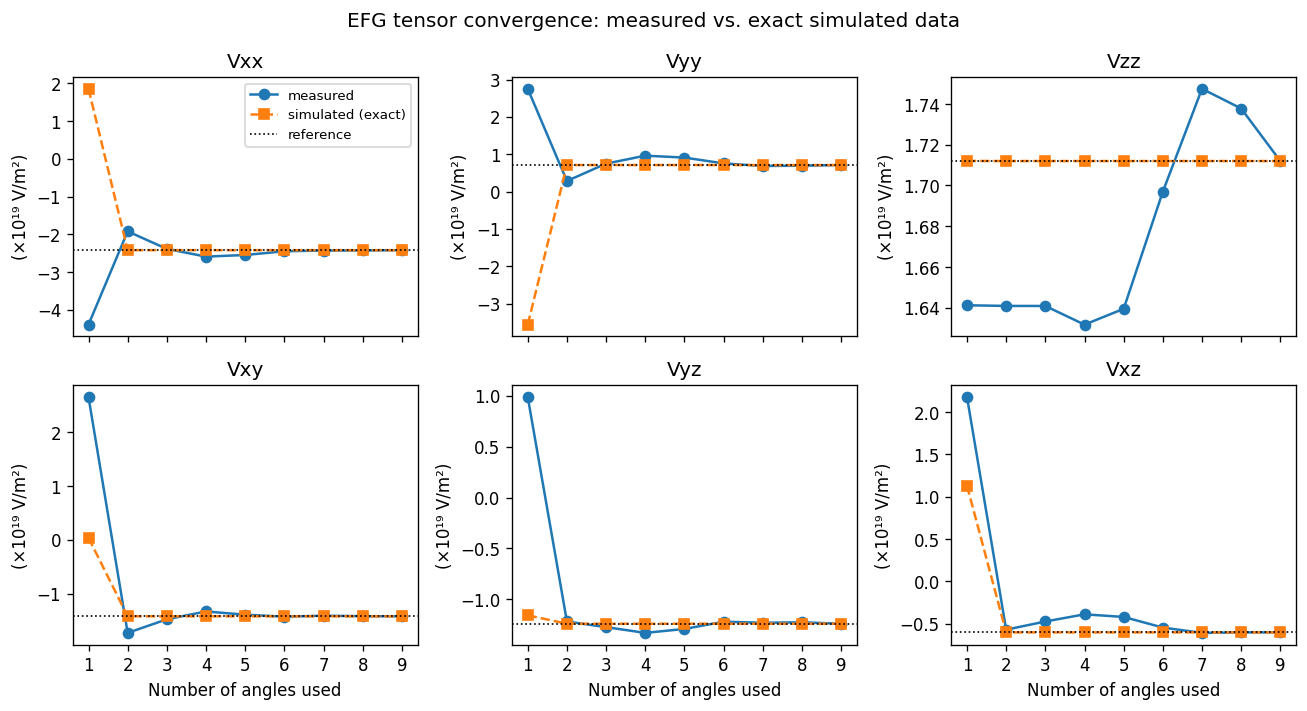

In [118]:
ns = list(range(1, len(thetas) + 1))

fig, axes = plt.subplots(2, 3, figsize=(11, 6), dpi=120, sharex=True)
axes = axes.flatten()

for ax, name in zip(axes, param_names):
    ref = p_converged[name]
    vals_meas = [conv_measured[n][name] if conv_measured[n] else np.nan for n in ns]
    vals_sim  = [conv_sim[n][name]      if conv_sim[n]      else np.nan for n in ns]
    ax.plot(ns, vals_meas, 'o-',  color='C0', label='measured')
    ax.plot(ns, vals_sim,  's--', color='C1', label='simulated (exact)')
    ax.axhline(ref, color='k', linestyle=':', linewidth=1, label='reference')
    ax.set_title(name)
    ax.set_ylabel('(×10¹⁹ V/m²)')
    ax.set_xticks(ns)

for ax in axes[-3:]:
    ax.set_xlabel('Number of angles used')
axes[0].legend(fontsize=8)

fig.suptitle('EFG tensor convergence: measured vs. exact simulated data', fontsize=12)
fig.tight_layout()

## Convergence: how many angles are needed? - measured data

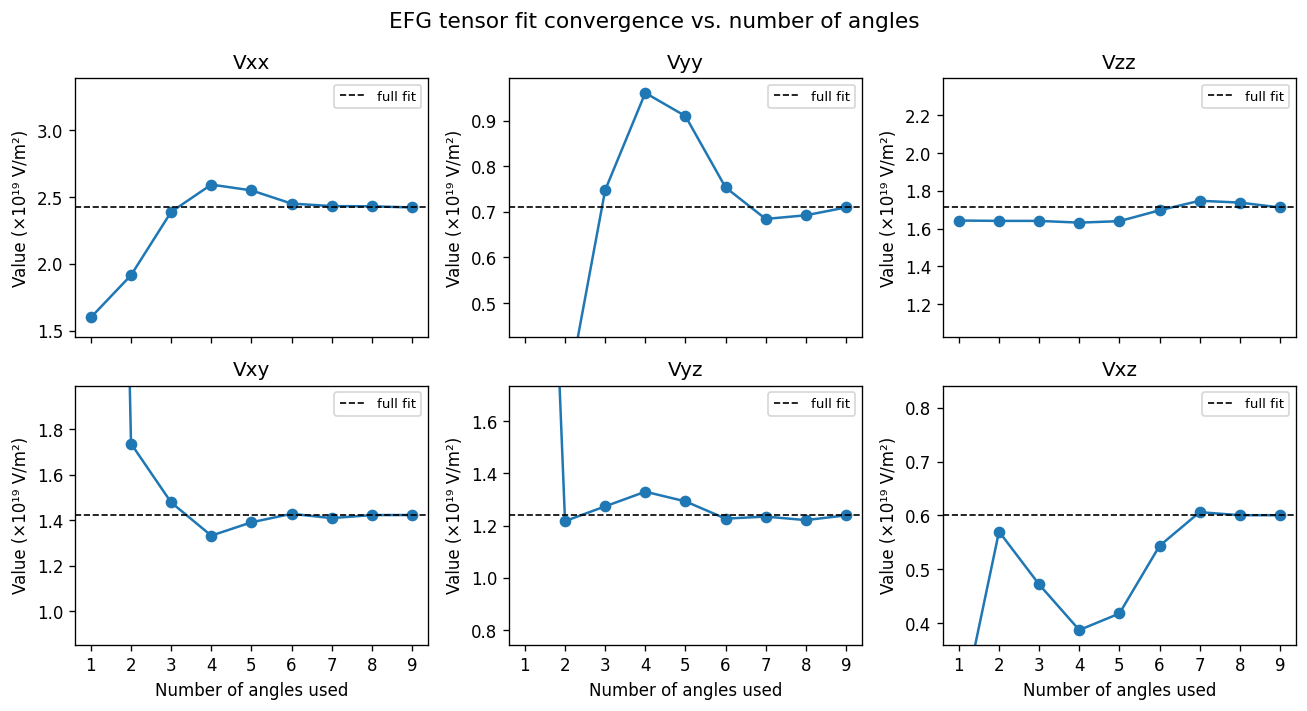

In [113]:
param_names = ['Vxx', 'Vyy', 'Vzz', 'Vxy', 'Vyz', 'Vxz']
p_full = result.params.valuesdict()

conv_results = {}  # n_angles → fitted param dict

guesses = np.random.uniform(-10, 10, size=5)
guesses = np.zeros(5)

for n in range(1, len(thetas) + 1):
    thetas_sub  = thetas[:n]
    nmr_sub     = nmr[:n]
    nmr_centered_sub = nmr_sub - nmr_sub.mean(axis=1, keepdims=True)

    def residual_sub(params):
        p = params.valuesdict()
        res = []
        for t, theta in enumerate(thetas_sub):
            freq_model = nmr_frequencies(theta, **p)
            freq_model_centered = freq_model - freq_model.mean()
            res.append((freq_model_centered - nmr_centered_sub[t]))
        return np.hstack(res)

    p0 = Parameters()
    p0.add('Vxx', value=guesses[0],  min=-10,  max=5)
    p0.add('Vyy', value=guesses[1], min=-10,  max=5)
    p0.add('Vzz', expr='-Vxx - Vyy')
    p0.add('Vxy', value=guesses[2], min=-20, max=20)
    p0.add('Vyz', value=guesses[3], min=-10,  max=20)
    p0.add('Vxz', value=guesses[4],  min=-10,  max=20)


    r = minimize(residual_sub, p0, method='leastsq')
    conv_results[n] = r.params.valuesdict()


ns = [n for n, v in conv_results.items() if v is not None]
p_converged = result.params.valuesdict()  # full-data fit as reference

fig, axes = plt.subplots(2, 3, figsize=(11, 6), dpi=120, sharex=True)
axes = axes.flatten()

for ax, name in zip(axes, param_names):
    vals = [conv_results[n][name] for n in ns]
    ref  = p_converged[name]
    ax.plot(ns, np.abs(vals), 'o-', color='C0')
    ax.axhline(np.abs(ref), color='k', linestyle='--', linewidth=1, label='full fit')
    ax.set_title(name)
    ax.set_ylabel('Value (×10¹⁹ V/m²)')
    ax.set_xticks(range(1, len(thetas) + 1))
    ax.set_ylim(np.abs(ref) - 0.4 * np.abs(ref), np.abs(ref) + 0.4 * np.abs(ref))
    ax.legend(fontsize=8)

for ax in axes[-3:]:
    ax.set_xlabel('Number of angles used')

fig.suptitle('EFG tensor fit convergence vs. number of angles', fontsize=13)
fig.tight_layout()

# second fit with minimum datapoints

In [82]:
# Round 2 data: 9 angles, 7 NMR transition frequencies each
nmr = np.flip(np.array([
    [5177528, 5196914, 5216357, 5235865, 5255417, 5275028, 5294686],
    [5161529, 5169044, 5176984, 5185315, 5194063, 5203187, 5212704],
    # [5193097, 5181625, 5170701, 5160363, 5150582, 5141366, 5132727],
    # [5061216, 5033579, 5006232, 4979215, 4952508, 4926134, 4900099],
    # [4979932, 4949389, 4918974, 4888688, 4858533, 4828508, 4798611],
    # [4999724, 4982724, 4965998, 4949547, 4933377, 4917481, 4901852],
    # [5104750, 5108384, 5112255, 5116361, 5120679, 5125222, 5129953],
    # [5097951, 5116198, 5134431, 5152658, 5170888, 5189117, 5207340],
    # [5175598, 5195010, 5214485, 5234018, 5253596, 5273241, 5292925]
], dtype=float), axis=1)

thetas = np.array([0, 22.5,
                   # 45,
                   # 67.5, 90, 112.5, 135, 157.5, 180
                  ]) / 180 * np.pi

# B0 estimated from central transition at theta=0
B0 = np.mean(nmr[0]) / GAMMA_NUCLEAR

In [65]:
# Per-angle mean of measured frequencies (absorbs B0 variation)
nmr_means = nmr.mean(axis=1, keepdims=True)
nmr_centered = nmr - nmr_means
scale = np.abs(nmr_centered).max()

params = Parameters()
params.add('Vxx', value=2.4,  min=-5,  max=5)
params.add('Vyy', value=-0.7, min=-5,  max=5)
params.add('Vzz', expr='-Vxx - Vyy')
params.add('Vxy', value=-1.5, min=-20, max=20)
params.add('Vyz', value=-1.2, min=-5,  max=20)
params.add('Vxz', value=0.6,  min=-5,  max=20)

result = minimize(residual, params, method='leastsq')
result.params

name,value,standard error,relative error,initial value,min,max,vary,expression
Vxx,-2.53941287,3.2702e-05,(0.00%),2.4,-5.00000000,5.00000000,True,
Vyy,0.89848869,4.6952e-05,(0.01%),-0.7,-5.00000000,5.00000000,True,
Vzz,1.64092418,3.2699e-05,(0.00%),-1.7,-inf,inf,False,-Vxx - Vyy
Vxy,-1.21156087,0.14857856,(12.26%),-1.5,-20.0000000,20.0000000,True,
Vyz,-1.09477749,0.16444469,(15.02%),-1.2,-5.00000000,20.0000000,True,
Vxz,-0.81365392,0.16587005,(20.39%),0.6,-5.00000000,20.0000000,True,


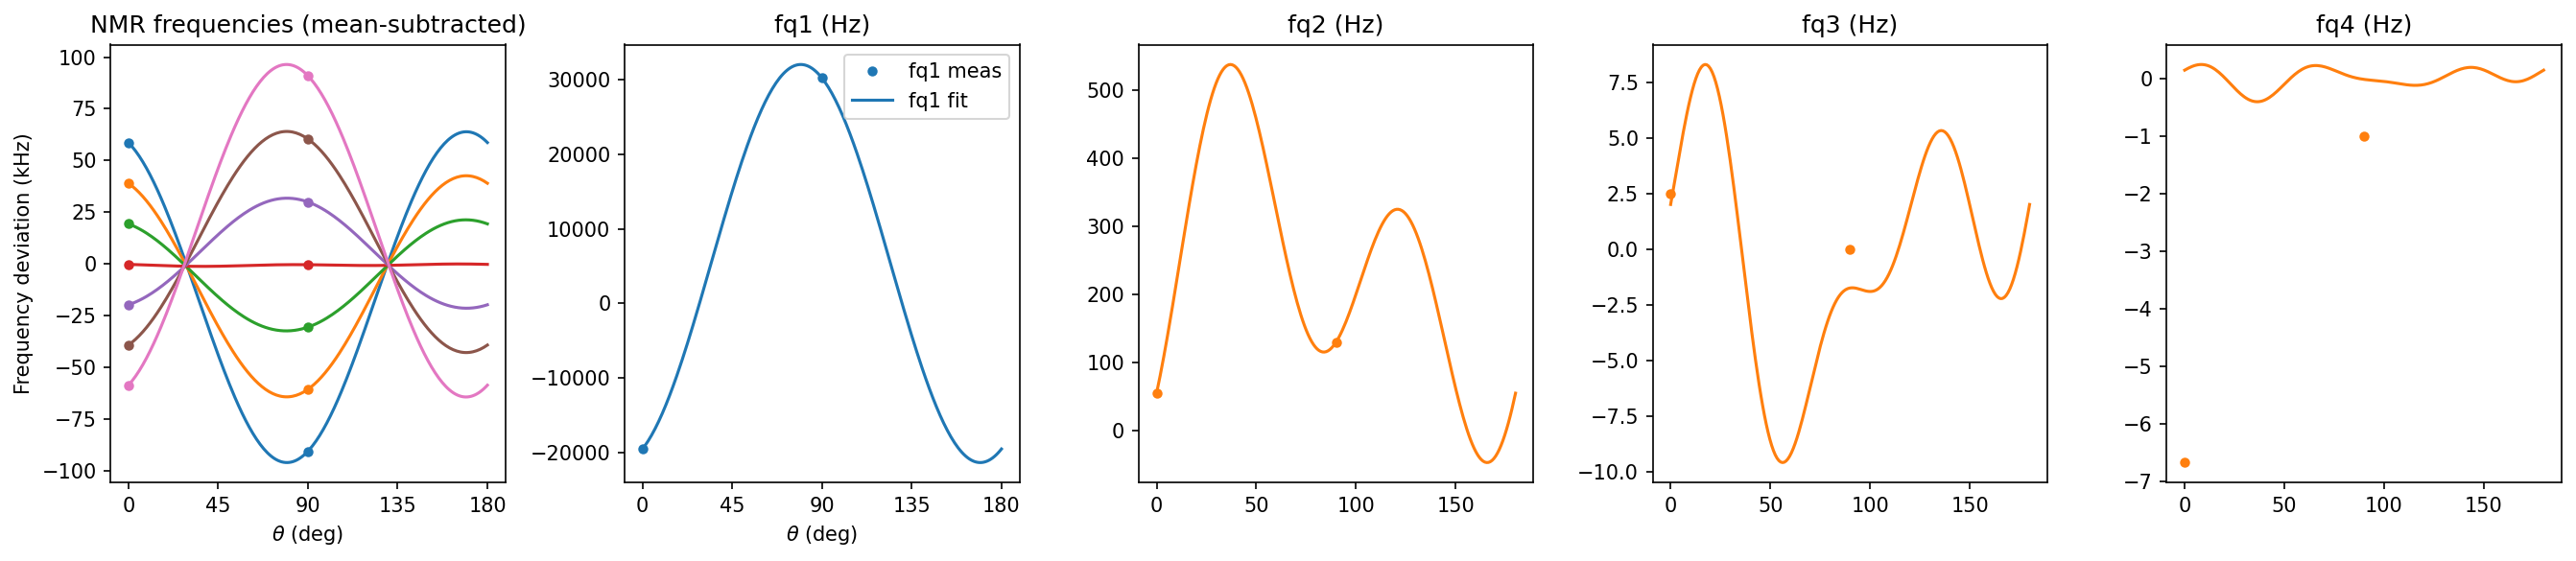

In [66]:
p = result.params.valuesdict()
thetas_fine = np.linspace(0, np.pi, 200)

nmr_model = np.array([nmr_frequencies(th, **p) for th in thetas_fine])
nmr_model_centered = nmr_model - nmr_model.mean(axis=1, keepdims=True)

colors = plt.cm.tab10.colors
theta_deg = thetas / np.pi * 180
theta_fine_deg = thetas_fine / np.pi * 180

fq1_meas = np.array([np.mean(np.diff(nmr[t])) for t in range(len(thetas))])
fq2_meas = np.array([np.mean(np.diff(np.diff(nmr[t]))) for t in range(len(thetas))])
fq3_meas = np.array([np.mean(np.diff(np.diff(np.diff(nmr[t])))) for t in range(len(thetas))])
fq4_meas = np.array([np.mean(np.diff(np.diff(np.diff(np.diff(nmr[t]))))) for t in range(len(thetas))])

fq1_model = np.array([np.mean(np.diff(np.diff(ionized_hamiltonian(th, **p).eigenstates()[0])))
                      for th in thetas_fine])
fq2_model = np.array([np.mean(np.diff(np.diff(np.diff(ionized_hamiltonian(th, **p).eigenstates()[0]))))
                      for th in thetas_fine])

fq2_guess = np.array([np.mean(np.diff(np.diff(np.diff(ionized_hamiltonian(th, **p).eigenstates()[0]))))
                      for th in thetas])

fq3_model = np.array([np.mean(np.diff(np.diff(np.diff(np.diff(ionized_hamiltonian(th, **p).eigenstates()[0]))))) for th in thetas_fine])
fq4_model = np.array([np.mean(np.diff(np.diff(np.diff(np.diff(np.diff(ionized_hamiltonian(th, **p).eigenstates()[0])))))) for th in thetas_fine])

fig, axes = plt.subplots(1, 5, figsize=(18, 4), dpi=150)

for i in range(7):
    c = colors[i % len(colors)]
    axes[0].plot(theta_deg, nmr_centered[:, i] * 1e-3, '.', markersize=8, color=c)
    axes[0].plot(theta_fine_deg, nmr_model_centered[:, i] * 1e-3, color=c)
axes[0].set_title('NMR frequencies (mean-subtracted)')
axes[0].set_xlabel(r'$\theta$ (deg)')
axes[0].set_ylabel('Frequency deviation (kHz)')
axes[0].set_xticks([0, 45, 90, 135, 180])

axes[1].plot(theta_deg, fq1_meas, '.', markersize=8, label='fq1 meas', color='C0')
axes[1].plot(theta_fine_deg, fq1_model, color='C0', label='fq1 fit')


axes[2].plot(theta_deg, fq2_meas, '.', markersize=8, label='fq2 meas', color='C1')
axes[2].plot(theta_fine_deg, fq2_model, color='C1', label='fq2 fit')

axes[3].plot(theta_deg, fq3_meas, '.', markersize=8, label='fq2 meas', color='C1')
axes[3].plot(theta_fine_deg, fq3_model, color='C1', label='fq2 fit')

axes[4].plot(theta_deg, fq4_meas, '.', markersize=8, label='fq2 meas', color='C1')
axes[4].plot(theta_fine_deg, fq4_model, color='C1', label='fq2 fit')

axes[1].set_title('fq1 (Hz)')
axes[2].set_title('fq2 (Hz)')
axes[3].set_title('fq3 (Hz)')
axes[4].set_title('fq4 (Hz)')

axes[1].set_xlabel(r'$\theta$ (deg)')
axes[1].set_xticks([0, 45, 90, 135, 180])
axes[1].legend()

fig.tight_layout()

## compare

## 0 and 90 degrees

In [67]:
# Round 2 data: 9 angles, 7 NMR transition frequencies each
nmr = np.flip(np.array([
    [5177528, 5196914, 5216357, 5235865, 5255417, 5275028, 5294686],
    # [5161529, 5169044, 5176984, 5185315, 5194063, 5203187, 5212704],
    # [5193097, 5181625, 5170701, 5160363, 5150582, 5141366, 5132727],
    # [5061216, 5033579, 5006232, 4979215, 4952508, 4926134, 4900099],
    [4979932, 4949389, 4918974, 4888688, 4858533, 4828508, 4798611],
    # [4999724, 4982724, 4965998, 4949547, 4933377, 4917481, 4901852],
    # [5104750, 5108384, 5112255, 5116361, 5120679, 5125222, 5129953],
    # [5097951, 5116198, 5134431, 5152658, 5170888, 5189117, 5207340],
    # [5175598, 5195010, 5214485, 5234018, 5253596, 5273241, 5292925]
], dtype=float), axis=1)

thetas = np.array([0,
                   # 22.5,
                   # 45,
                   # 67.5,
                   90,
                   # 112.5, 135, 157.5, 180
                  ]) / 180 * np.pi

# B0 estimated from central transition at theta=0
B0 = np.mean(nmr[0]) / GAMMA_NUCLEAR

In [68]:
# Per-angle mean of measured frequencies (absorbs B0 variation)
nmr_means = nmr.mean(axis=1, keepdims=True)
nmr_centered = nmr - nmr_means
scale = np.abs(nmr_centered).max()

params = Parameters()
params.add('Vxx', value=2.4,  min=-5,  max=5)
params.add('Vyy', value=-0.7, min=-5,  max=5)
params.add('Vzz', expr='-Vxx - Vyy')
params.add('Vxy', value=-1.5, min=-20, max=20)
params.add('Vyz', value=-1.2, min=-5,  max=20)
params.add('Vxz', value=0.6,  min=-5,  max=20)

result = minimize(residual, params, method='leastsq')
result.params

name,value,standard error,relative error,initial value,min,max,vary,expression
Vxx,-2.53941287,3.2702e-05,(0.00%),2.4,-5.00000000,5.00000000,True,
Vyy,0.89848869,4.6952e-05,(0.01%),-0.7,-5.00000000,5.00000000,True,
Vzz,1.64092418,3.2699e-05,(0.00%),-1.7,-inf,inf,False,-Vxx - Vyy
Vxy,-1.21156087,0.14857856,(12.26%),-1.5,-20.0000000,20.0000000,True,
Vyz,-1.09477749,0.16444469,(15.02%),-1.2,-5.00000000,20.0000000,True,
Vxz,-0.81365392,0.16587005,(20.39%),0.6,-5.00000000,20.0000000,True,
